In [16]:
import os, cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D, Flatten, Dense,
                                     Dropout, BatchNormalization)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import ReduceLROnPlateau

In [13]:
# 💡 RGB로 이미지 로드
def load_images_rgb(folder, label, image_size=(64, 64)):
    data = []
    for filename in os.listdir(folder):
        if not (filename.endswith('.jpg') or filename.endswith('.png')):
            continue
        path = os.path.join(folder, filename)
        img = cv2.imread(path)  # BGR로 로드
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # RGB로 변환
        img = cv2.resize(img, image_size)
        data.append((img / 255.0, label))
    return data

# 🐱🐶 데이터 로딩
cat_data = load_images_rgb("data/cats2", 0)
dog_data = load_images_rgb("data/dogs2", 1)

dataset = cat_data[:1000] + dog_data[:1000]
np.random.shuffle(dataset)

X = np.array([x[0] for x in dataset])
y = np.array([x[1] for x in dataset])
y = to_categorical(y, num_classes=2)

# 학습/테스트 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
# ✅ 개선된 CNN 모델
model = Sequential([
    Input(shape=(64, 64, 3)),
    
    Conv2D(32, (3,3), activation='relu', padding='same', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),
    Dropout(0.3),

    Conv2D(64, (3,3), activation='relu', padding='same', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),
    Dropout(0.35),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),
    Dropout(0.4),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(2, activation='softmax')
])

# ✅ 모델 컴파일 
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# ✅ 콜백 설정
early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)


# ✅ 증강기 강화
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    shear_range=0.1,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True,
)
datagen.fit(X_train)

# ✅ 학습
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=40,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, reduce_lr]
)


Epoch 1/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 16s 251ms/step - accuracy: 0.4844 - loss: 1.8178 - val_accuracy: 0.4825 - val_loss: 0.7414 - learning_rate: 0.0010
Epoch 2/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 243ms/step - accuracy: 0.4756 - loss: 0.9226 - val_accuracy: 0.5650 - val_loss: 0.7403 - learning_rate: 0.0010
Epoch 3/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 241ms/step - accuracy: 0.5047 - loss: 0.7604 - val_accuracy: 0.4900 - val_loss: 0.7417 - learning_rate: 0.0010
Epoch 4/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 13s 252ms/step - accuracy: 0.5055 - loss: 0.7543 - val_accuracy: 0.5150 - val_loss: 0.7411 - learning_rate: 0.0010
Epoch 5/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 13s 249ms/step - accuracy: 0.5255 - loss: 0.7589 - val_accuracy: 0.4800 - val_loss: 0.7387 - learning_rate: 0.0010
Epoch 6/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 244ms/step - accuracy: 0.4970 - loss: 0.7491 - val_accuracy: 0.5125 - val_loss: 0.7360 - learning_rate: 0.0010
Epoch 7/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 243ms/step - accuracy: 0.5060 - loss: 0.

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.5330 - loss: 0.7303


🎯 최종 테스트 정확도: 0.52


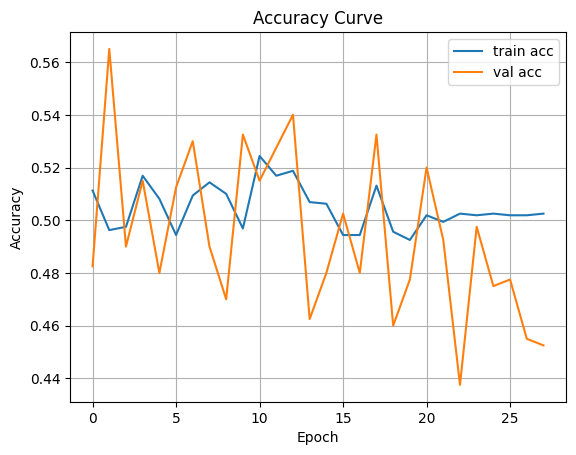

In [17]:
# ✅ 테스트 정확도
loss, acc = model.evaluate(X_test, y_test)
print(f"🎯 최종 테스트 정확도: {acc:.2f}")

model.save("models/cnn_rgb_model.h5")

# ✅ 손실 곡선 시각화
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()